# Cancer Growth Dynamics: Treated MonoCulture Analysis
## IC25, IC50, IC75 Dose Response Modeling (20k Density)

**Fixed Drug Concentrations:**
- IC25: 1.47 µM (25% inhibition target) 
- IC50: 1.00 µM (50% inhibition reference)
- IC75: 0.62 µM (75% inhibition target)

**Cell Lines:** A2780 (naive) and A2780cis (cisplatin-resistant)

## Mathematical Model Description

### Core Model: Drug-Modified Logistic Growth

Your model combines **logistic growth** with **Hill equation dose-response** to describe cancer cell growth under drug treatment:

**Differential Equation:**
```
dN/dt = r_eff × N × (1 - N/K_eff)
```

Where:
- **N(t)** = Number of cells at time t
- **r_eff** = Effective growth rate (drug-modified)
- **K_eff** = Effective carrying capacity (drug-modified)

### Drug Effects via Hill Equation

The drug modifies both growth parameters through Hill dose-response relationships:

**Hill Function:**
```
inhibition = dose^n / (IC50^n + dose^n)
```

### Hierarchical Model Fitting Strategy

The analysis tries **5 model variants** in order of complexity until one succeeds:

**Model 2: Single Hill (3 parameters)**
- **n** = Single Hill coefficient for both effects
- **α_r** = Maximum growth rate inhibition
- **α_K** = Maximum carrying capacity inhibition


### Optimization Strategy

**Local Optimization:**
- Multiple optimizers: BFGS, LBFGS, NelderMead
- Multiple starting points for each optimizer
- Best result selected across all attempts

**Global Optimization:**
- Grid search for simpler models (≤3 parameters)
- Used as backup when local optimization fails

### Fixed Parameters

**From untreated controls:**
- **r** = Intrinsic growth rate
- **K** = Carrying capacity  
- **IC50** = 1.0 µM (reference concentration, fixed)

### Experimental Design

**Dose Conditions:**
- **IC25**: 1.47 µM (25% inhibition target)
- **IC50**: 1.00 µM (50% inhibition reference) 
- **IC75**: 0.62 µM (75% inhibition target)

**Cell Lines:**
- **A2780 (naive)** - Cisplatin-sensitive
- **A2780cis** - Cisplatin-resistant

**Total Analysis:** 6 conditions (3 doses × 2 cell lines), each fitted with best available model

## 1) Packages and Imports

In [1]:
# Install required packages if not already installed
using Pkg
Pkg.add(["CSV", "DataFrames", "Statistics", "DifferentialEquations", "Optim", "Plots", "LinearAlgebra", "ForwardDiff"])

# Load required packages
using CSV, DataFrames, Statistics
using DifferentialEquations, Optim, Plots
using LinearAlgebra, Printf
using Base.Threads
using ForwardDiff

# Performance settings
BLAS.set_num_threads(min(4, Threads.nthreads()))
gr(fmt=:png, dpi=150)

println("✅ Essential packages loaded:")
println("  • Data: CSV, DataFrames, Statistics") 
println("  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff")
println("  • Visualization: Plots (GR backend)")
println("  • Performance: Base.Threads ($(Threads.nthreads()) threads), BLAS ($(BLAS.get_num_threads()) threads)")
println("  • Utilities: Printf")
println("✅ Setup completed - ready for analysis!")

   Resolving package versions...
  No Changes to `C:\Users\elbak\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.10\Manifest.toml`


✅ Essential packages loaded:
  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
✅ Setup completed - ready for analysis!


## 2) Paths and Data Directories

In [2]:
# Set up paths for IC25, IC50, IC75 data
# Since we're in a notebook, we need to construct the ROOT path from current working directory
ROOT = dirname(dirname(pwd()))

# Data directories for each dose
IC25_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC25", "Averages")
IC50_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")  
IC75_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")

# Output directory
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "Multi_Dose_Analysis")
isdir(OUT_DIR) || mkpath(OUT_DIR)

# Baseline parameters file
RK_FILE = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")

println("📁 Data paths configured:")
println("  IC25 (1.47µM): $(isdir(IC25_DIR) ? "✅" : "❌") $IC25_DIR")
println("  IC50 (1.00µM): $(isdir(IC50_DIR) ? "✅" : "❌") $IC50_DIR")
println("  IC75 (0.62µM): $(isdir(IC75_DIR) ? "✅" : "❌") $IC75_DIR")
println("  Output: $OUT_DIR")
println("  Parameters: $(isfile(RK_FILE) ? "✅" : "❌") $RK_FILE")

using CSV, DataFrames

function load_day_averages_with_day0(path::AbstractString)
    @assert isfile(path) "Missing file: $path"
    df = CSV.read(path, DataFrame)

    # Exact column names from your processed data
    day_col    = findfirst(n -> String(n) == "Day",        names(df))
    mean_col   = findfirst(n -> String(n) == "Mean Cells", names(df))
    stderr_col = findfirst(n -> String(n) == "SEM Cells",  names(df))

    @assert day_col !== nothing && mean_col !== nothing "Could not find required columns in $path. Available: $(names(df))"

    x    = Float64.(df[!, day_col])
    y    = Float64.(df[!, mean_col])
    yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))

    # Sort
    p = sortperm(x); x, y, yerr = x[p], y[p], yerr[p]

    # Insert day 0 (67 for 20k, 100 for 30k)
    if minimum(x) > 0.1
        dens = occursin("20k", path) ? "20k" : (occursin("30k", path) ? "30k" : "20k")
        day0_cells = dens == "20k" ? 67.0 : 100.0
        x    = vcat([0.0], x)
        y    = vcat([day0_cells], y)
        yerr = vcat([max(day0_cells * 0.1, 1.0)], yerr)  # floor std error
    end

    # Limit to 0–12 days
    mask = x .<= 12.0
    return x[mask], y[mask], yerr[mask]
end

📁 Data paths configured:
  IC25 (1.47µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
  IC50 (1.00µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
  IC75 (0.62µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
  Output: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis
  Parameters: ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv


load_day_averages_with_day0 (generic function with 1 method)

## 3) Utility Functions

In [3]:
# 2) Define dose directories and numeric values
dose_conditions = [
    ("IC25", 1.47, IC25_DIR),  # IC25 = 1.47 µM
    ("IC50", 1.00, IC50_DIR),  # IC50 = 1.00 µM
    ("IC75", 0.62, IC75_DIR),  # IC75 = 0.62 µM
]

function analyze_dose_set(
    dose_name::AbstractString,
    dose_value::Float64,
    data_dir::AbstractString,
    rk_params;                     # now contains (r, K, v) tuples
    IC50_fixed::Float64 = 1.0
)
    results = Dict{Symbol,Any}()

    # Ensure loader exists even if earlier cells were not run
    if !isdefined(@__MODULE__, :load_day_averages_with_day0)
        @eval begin
            function load_day_averages_with_day0(path::AbstractString)
                @assert isfile(path) "Missing file: $path"
                df = CSV.read(path, DataFrame)
                day_col = findfirst(n -> String(n) == "Day", names(df))
                mean_col = findfirst(n -> String(n) == "Mean Cells", names(df))
                stderr_col = findfirst(n -> String(n) == "SEM Cells", names(df))
                @assert day_col !== nothing && mean_col !== nothing "Could not find required columns in $path. Available columns: $(names(df))"
                x = Float64.(df[!, day_col])
                y = Float64.(df[!, mean_col])
                yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))
                perm = sortperm(x); x, y, yerr = x[perm], y[perm], yerr[perm]
                if minimum(x) > 0.1
                    dens = occursin("20k", path) ? "20k" : (occursin("30k", path) ? "30k" : "20k")
                    day0_cells = dens == "20k" ? 67.0 : 100.0
                    x = vcat([0.0], x)
                    y = vcat([day0_cells], y)
                    yerr = vcat([max(day0_cells * 0.1, 1.0)], yerr)
                end
                mask = x .<= 12.0
                return x[mask], y[mask], yerr[mask]
            end
            println("🔧 Defined load_day_averages_with_day0 (fallback)")
        end
    end

    println("🔬 Analyzing $dose_name ($(dose_value)µM)...")

    for (cell_line, params) in rk_params
        # Expect rk_params[cell_line] == (r, K, v)
        r, K, v = params

        cell_file = joinpath(data_dir, "$(String(cell_line))_day_averages.csv")
        print("  $(String(cell_line)): ")

        if !isfile(cell_file)
            println("❌ File not found")
            continue
        end

        try
            x, y, yerr = load_day_averages_with_day0(cell_file)

            if length(x) < 5 || any(y .<= 0)
                println("❌ Insufficient or invalid data")
                continue
            end

            # v now comes from rk_params, no v_params
            fit_result = fit_dose_response(
                x, y, yerr,
                r, K, v,
                dose_value;
                IC50_fixed = IC50_fixed
            )

            if fit_result === nothing
                println("? Fitting failed" * (isdefined(Main, Symbol("FIT_FAIL_REASON")) ? " - " * (getfield(Main, Symbol("FIT_FAIL_REASON"))[]) : ""))
                continue
            end

            results[cell_line] = fit_result
            println("✅ n=$(round(fit_result.n, digits=2)), Emax=$(round(fit_result.Emax, digits=2)), inhibition=$(round(fit_result.inhibition * 100, digits=1))%")

        catch e
            println("❌ Error - $e")
        end
    end

    return results
end



analyze_dose_set (generic function with 1 method)

## 4) Hill function and dose helpers

In [4]:
# ============================================
# 2) Hill function and dose helpers
# ============================================

# Standard Hill function: H ∈ (0,1)
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

"""
    calculate_dose_for_inhibition(H, IC50; n=1.0)

Given target inhibition H in (0,1), IC50, and Hill coefficient n > 0,
solve H = dose^n / (IC50^n + dose^n) for dose:

    dose = IC50 * (H / (1 - H))^(1/n)
"""
function calculate_dose_for_inhibition(H, IC50; n::Float64 = 1.0)
    if H <= 0.0 || H >= 1.0 || IC50 <= 0.0 || n <= 0.0
        return NaN
    end
    return IC50 * (H / (1 - H))^(1 / n)
end

function calculate_dose_range(target_inhibitions, IC50; n::Float64 = 1.0)
    return [calculate_dose_for_inhibition(H, IC50; n=n) for H in target_inhibitions]
end

println("✅ Hill utilities loaded")
println("  • hill(dose, IC50, n)")
println("  • calculate_dose_for_inhibition / calculate_dose_range")

# ============================================
# 3) Theta-logistic × (1 - death_term) model
# ============================================

# Model:
#   growth = r P (1 - (P/K)^v)
#   death_term = Emax * H(dose(t)),  0 ≤ Emax ≤ 1
#   dP/dt = growth * (1 - death_term)
#
# Parameters:
#   r     : intrinsic growth rate (day⁻¹)
#   K     : carrying capacity (cells)
#   v     : crowding exponent (theta)
#   Emax  : maximal fractional inhibition (dimensionless, 0–1)
#   IC50  : half-max concentration
#   n     : Hill coefficient
#
# dose_fun(t) encodes the dosing schedule (constant or time-varying).

function treated_theta_logistic_mult!(du, u, p, t, dose_fun)
    r, K, v, Emax, IC50, n = p
    P = u[1]

    dose = dose_fun(t)
    H = hill(dose, IC50, n)              # ∈ (0,1)
    death_term = Emax * H                # ∈ (0,Emax)

    # Clamp to avoid negative factor numerically
    death_term = min(max(death_term, 0.0), 0.999)

    growth = r * P * (1 - (P / K)^v)
    du[1] = growth * (1 - death_term)
end

"""
    solve_treated_theta_logistic_mult(x, r, K, v;
                                      Emax=0.5,
                                      IC50=1.0,
                                      n=1.0,
                                      dose=1.0,
                                      y0=nothing,
                                      dose_fun=nothing)

Solve the theta-logistic model with multiplicative Hill inhibition:

    dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose(t)))

If `dose_fun` is not provided, uses a constant dose.
If `y0` is not provided, uses K * (0.018 / 0.95) as seeding (calculated by hand).

Returns: `sol` with `sol.t == x`.
"""
function solve_treated_theta_logistic_mult(
    x,
    r::Float64,
    K::Float64,
    v::Float64;
    Emax::Float64 = 0.5,
    IC50::Float64 = 1.0,
    n::Float64    = 1.0,
    dose::Float64 = 1.0,
    y0::Union{Nothing,Float64} = nothing,
    dose_fun::Union{Nothing,Function} = nothing,
)
    x = collect(Float64.(x))

    # initial condition
    if y0 === nothing
        # seeding rule from your plate setup (calculated by hand)
        y0 = K * (0.018 / 0.95)
    end

    # time span
    t0    = minimum(x)
    t_end = maximum(x)
    tspan = (t0, t_end)

    # dosing schedule
    local_dose_fun = dose_fun === nothing ? (t -> dose) : dose_fun

    # parameter vector: (r, K, v, Emax, IC50, n)
    p = [r, K, v, Emax, IC50, n]

    f = (du, u, p, t) -> treated_theta_logistic_mult!(du, u, p, t, local_dose_fun)
    prob = ODEProblem(f, [y0], tspan, p)

    sol = solve(prob, Tsit5();
                saveat = x,
                reltol = 1e-6,
                abstol = 1e-8,
                maxiters = 1000)

    return sol
end

println("✅ Theta-logistic × (1 - death_term) model loaded")
println("  • dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose))")
println("  • Emax is max fractional inhibition (0–1)")
println("  • Supports constant or time-varying dose_fun(t)")


✅ Hill utilities loaded
  • hill(dose, IC50, n)
  • calculate_dose_for_inhibition / calculate_dose_range
✅ Theta-logistic × (1 - death_term) model loaded
  • dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose))
  • Emax is max fractional inhibition (0–1)
  • Supports constant or time-varying dose_fun(t)


## 5) Fitting Functions

In [5]:
using Optim

# Put this right above/with fit_dose_response
if !isdefined(Main, :FIT_FAIL_REASON)
    const FIT_FAIL_REASON = Ref("")
else
    FIT_FAIL_REASON[] = ""   # clear reason between analyses
end
#Stable, log-domain Hill function (dose and IC50 > 0)
hill_log(dose::Float64, IC50::Float64, n::Float64) = 1.0 / (1.0 + 10.0^(n * (log10(IC50) - log10(dose))))

function fit_dose_response(
    x::AbstractVector,
    y::AbstractVector,
    yerr::AbstractVector,
    r::Float64,
    K::Float64,
    v::Float64,
    dose::Float64;
    IC50_fixed::Float64 = 1.0,
    )
    # As arrays
    x = collect(Float64.(x))
    y = collect(Float64.(y))
    yerr = collect(Float64.(yerr))
    @assert length(x) == length(y) == length(yerr) "x, y, yerr must have same length"

    # Normalize by day-0 (stabilize scale)
    y0 = max(y[1], 1e-12)
    y_norm    = y ./ y0
    yerr_norm = yerr ./ y0

    # Bounds for parameters (Emax fractional inhibition, n Hill slope)
    E_lo, E_hi = 0.0, 1.0
    n_lo, n_hi = 0.5, 3.0

    eps_val = 1e-12
    w = 1.0 ./ (yerr_norm.^2 .+ eps_val)  # weight from normalized errors

    # Precompute Hill inhibition for fixed dose for speed/stability
    Hdose = hill_log(dose, IC50_fixed, 1.0)  # slope 1 used only to sanity check log domain
    @assert dose > 0 && IC50_fixed > 0 "dose and IC50_fixed must be > 0"

    function loss(params)
        Emax, n = params

        # Bounds via penalty
        if !(E_lo <= Emax <= E_hi && n_lo <= n <= n_hi)
            return 1e10
        end

        # Safe ODE solve with your theta-logistic + Hill death
        local sol
        try
            sol = solve_treated_theta_logistic_mult(
                x, r, K, v;
                Emax = Emax,
                IC50 = IC50_fixed,
                n    = n,
                dose = dose,
                y0   = y[1],   # keep original day-0 for the forward model
            )
        catch e
            FIT_FAIL_REASON[] = "loss exception: " * string(typeof(e))
            println("[fit] " * FIT_FAIL_REASON[])
            return 1e10
        end

        if sol.retcode != :Success
            FIT_FAIL_REASON[] = "ODE retcode=" * string(sol.retcode)
            println("[fit] " * FIT_FAIL_REASON[])
            return 1e9
        end

        pred = getindex.(sol.u, 1)
        if length(pred) != length(y)
            FIT_FAIL_REASON[] = "pred length mismatch"
            return 1e10
        end

        # Normalize model prediction by the same day-0
        pred_norm = pred ./ y0

        resid = y_norm .- pred_norm
        sse   = sum(w .* resid.^2)
        reg   = 1e-6 * (Emax^2 + n^2)  # light regularization
        return sse + reg
    end

    # Initial guesses from normalized data
    final_reduction = max(0.0, 1.0 - y_norm[end])
    E0 = clamp(final_reduction, E_lo, E_hi)
    n0 = clamp(dose / IC50_fixed, n_lo, n_hi)
    initial = [E0, n0]

    # Optimizer + concise logging
    println("[fit] Dose=" * string(dose) * ", initial=(Emax=" * string(round(initial[1], digits=3)) * ", n=" * string(round(initial[2], digits=3)) * ")")
    result = optimize(loss, initial, NelderMead(); iterations=500)
    println("[fit] Converged=" * string(Optim.converged(result)) * ", min=" * string(Optim.minimum(result)))

    if !Optim.converged(result)
        FIT_FAIL_REASON[] = "optimizer did not converge"
        return nothing
    end

    E_opt, n_opt = Optim.minimizer(result)

    # Final forward run for outputs
    sol_treated = try
        solve_treated_theta_logistic_mult(
            x, r, K, v;
            Emax = E_opt,
            IC50 = IC50_fixed,
            n    = n_opt,
            dose = dose,
            y0   = y[1],
        )
    catch
        FIT_FAIL_REASON[] = "final forward solve exception"
        return nothing
    end

    if sol_treated.retcode != :Success
        FIT_FAIL_REASON[] = "final ODE retcode=" * string(sol_treated.retcode)
        return nothing
    end

    y_pred = getindex.(sol_treated.u, 1)

    # Untreated baseline (Emax=0, dose=0) to compute inhibition
    sol_untreated = solve_treated_theta_logistic_mult(
        x, r, K, v;
        Emax = 0.0,
        IC50 = IC50_fixed,
        n    = 1.0,
        dose = 0.0,
        y0   = y[1],
    )
    untreated_final = last(getindex.(sol_untreated.u, 1))
    inhibition = max(0.0, (untreated_final - y_pred[end]) / max(untreated_final, 1e-12))

    return (
        x = x, y = y, yerr = yerr,
        y_pred = y_pred,
        r = r, K = K, v = v,
        dose = dose, IC50 = IC50_fixed,
        Emax = E_opt, n = n_opt,
        inhibition = inhibition,
        ssr = Optim.minimum(result),
        converged = true,
        sol_treated = sol_treated,
        sol_untreated = sol_untreated,
    )
end

fit_dose_response (generic function with 1 method)

## 6) Load Baseline Parameters and Raw Data

In [6]:
using CSV, DataFrames

"""
    load_baseline_parameters(file::AbstractString)

Load baseline theta-logistic parameters (r, K, v) from a CSV file with columns:
File, Density, CellLine, r, K, v, SSR, BIC.

Returns a Dict mapping cell line Symbols → (r, K, v).
If duplicates (e.g. 20k vs. 30k) exist, keeps the row with smaller BIC.
"""
function load_baseline_parameters(file::AbstractString)
    @assert isfile(file) "Missing baseline file: $file"

    df = CSV.read(file, DataFrame)

    required = [:CellLine, :r, :K, :v, :BIC]
    missing_cols = setdiff(required, Symbol.(names(df)))
    @assert isempty(missing_cols) "Missing columns: $(missing_cols)"

    # group by CellLine and keep best (lowest BIC)
    grouped = groupby(df, :CellLine)
    best_rows = combine(grouped) do sub
        sub[argmin(sub.BIC), :]
    end

    params = Dict{Symbol, Tuple{Float64, Float64, Float64}}()
    for row in eachrow(best_rows)
        cell = Symbol(row.CellLine)
        params[cell] = (Float64(row.r), Float64(row.K), Float64(row.v))
    end

    return params
end
println("📊 Loading baseline parameters...")
rk_params = load_baseline_parameters(RK_FILE)

println("✅ Baseline parameters loaded:")
for (cell_line, (r, K, v)) in rk_params
    println("  $(String(cell_line)): r=$(round(r, digits=4)), K=$(round(K, digits=1)), v=$(round(v, digits=3))")
end

dose_conditions = [
    ("IC25", 1.47, IC25_DIR),
    ("IC50", 1.00, IC50_DIR),
    ("IC75", 0.62, IC75_DIR),
]


📊 Loading baseline parameters...
✅ Baseline parameters loaded:
  A2780cis: r=0.464, K=3793.4, v=3.547
  A2780Naive: r=1.1367, K=4077.2, v=0.624


3-element Vector{Tuple{String, Float64, String}}:
 ("IC25", 1.47, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC25\\Averages")
 ("IC50", 1.0, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC50\\Averages")
 ("IC75", 0.62, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC75\\Averages")

## 7) Running Function

In [7]:
# 1) Define dose directories and numeric values (as you already have)
dose_conditions = [
    ("IC25", 1.47, IC25_DIR),  # IC25 = 1.47 µM
    ("IC50", 1.00, IC50_DIR),  # IC50 = 1.00 µM
    ("IC75", 0.62, IC75_DIR),  # IC75 = 0.62 µM
]

# 2) Load baseline (r, K, v) parameters from untreated fits
rk_params = load_baseline_parameters(RK_FILE)  # must return (r, K, v)

# 3) Run dose–response fits for each dose
all_results = Dict{String,Dict{Symbol,Any}}()

for (dose_name, dose_value, data_dir) in dose_conditions
    println()
    println("============== $dose_name ==============")

    dose_results = analyze_dose_set(
        dose_name,
        dose_value,
        data_dir,
        rk_params;
        IC50_fixed = 1.0,
    )

    all_results[dose_name] = dose_results
end

println("\n✅ Dose–response modeling complete.")



============== IC25 ==============
🔬 Analyzing IC25 (1.47µM)...
  A2780cis: [fit] Dose=1.47, initial=(Emax=0.0, n=1.47)
❌ Error - MethodError(Core.kwcall, ((iterations = 500,), Optim.optimize, var"#loss#28"{Float64, Vector{Float64}, Vector{Float64}, Float64, Float64, Float64, Float64, Vector{Float64}, Float64, Float64, Float64, Float64, Vector{Float64}, Float64}(1.0, [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0], [67.0, 66.075347, 136.019406, 262.411998, 627.185185, 1055.706481, 1644.432755, 1888.79267, 1640.846373, 2390.450656, 1885.212654, 2693.787886, 2554.914468], 0.4640173809270667, 3793.3529986741078, 3.5467806509006525, 1.47, [99.99999998999998, 756.47579624667, 114.42472554955879, 50.39000265913415, 33.794154541363554, 3.9296361181652846, 0.7328279582292813, 0.4809147370842868, 0.5993261150513614, 1.7020276699682837, 0.9142635125803471, 0.4384012012346293, 0.34832295265993884], 3.0, 0.5, 1.0, 0.0, [1.0, 0.9861992089552238, 2.0301403880597015, 3.916596985

In [8]:
#Plot all the dose fits

"""
    plot_dose_fit(all_results, rk_params; save_dir=nothing)

Plot experimental data (points with error bars) and model predictions
for each dose and cell line. Optionally save figures into `save_dir`.
"""
function plot_dose_fit(all_results::Dict{String,Dict{Symbol,Any}},
                       rk_params::Dict{Symbol,Tuple{Float64,Float64,Float64}};
                       save_dir::Union{Nothing,String}=nothing)

    default(titlefont=font(12, "Arial"),
            guidefont=font(10, "Arial"),
            legendfontsize=9,
            lw=2, ms=5)

    for (dose_name, results) in all_results
        for (cell_line, fit) in results
            if fit === nothing
                @warn "No fit stored for $cell_line at $dose_name"
                continue
            end

            # Extract data
            x = fit.x
            y = fit.y
            yerr = fit.yerr
            y_pred = fit.y_pred

            # untreated comparison (for context)
            sol_unt = fit.sol_untreated
            y_unt = getindex.(sol_unt.u, 1)
            x_unt = sol_unt.t

            # Build plot
            p = plot(title = "$(String(cell_line)) — $(dose_name)",
                     xlabel = "Time (days)",
                     ylabel = "Cell count",
                     legend = :topright)

            # Experimental data
            scatter!(p, x, y; yerror=yerr, label="Data", color=:black, marker=:circle)

            # Untreated model (baseline)
            plot!(p, x_unt, y_unt; label="Untreated model", color=:gray, ls=:dash)

            # Treated model prediction
            plot!(p, x, y_pred; label="Fitted model", color=:blue)

            # Text info
            ann = @sprintf "Emax=%.2f, n=%.2f, inh=%.1f%%" fit.Emax fit.n fit.inhibition*100
            annotate!(p, (x[end]*0.6, maximum(vcat(y, y_pred))*0.8, text(ann, 9, :left)))

            display(p)

            # Optionally save
            if save_dir !== nothing
                isdir(save_dir) || mkpath(save_dir)
                file_name = joinpath(save_dir, "$(String(cell_line))_$(dose_name)_fit.png")
                savefig(p, file_name)
            end
        end
    end
end

# Example usage:
plot_dose_fit(all_results, rk_params; save_dir=OUT_DIR)


In [9]:
cell_color(name::AbstractString) = occursin("cis", lowercase(name)) ? :orange : :steelblue

function list_csvs(dir::AbstractString)
    if !isdir(dir)
    @warn "Directory not found: $dir"
    return String[]
    end
    files = filter(f -> endswith(lowercase(f), ".csv"), readdir(dir; join=true))
    return sort(files)
end

function safe_load_day_averages(path::AbstractString)
    if isdefined(Main, :load_day_averages_with_day0)
    return load_day_averages_with_day0(path)
    else
    df = CSV.read(path, DataFrame)
    day_col = findfirst(n -> String(n) == "Day", names(df))
    mean_col = findfirst(n -> String(n) == "Mean Cells", names(df))
    sem_col = findfirst(n -> String(n) == "SEM Cells", names(df))
    @assert day_col !== nothing && mean_col !== nothing "Columns Day/Mean Cells missing in $path"
    x = Float64.(df[!, day_col])
    y = Float64.(df[!, mean_col])
    yerr = sem_col === nothing ? nothing : Float64.(df[!, sem_col])
    perm = sortperm(x)
    x = x[perm]
    y = y[perm]
    yerr = yerr === nothing ? nothing : yerr[perm]
    return x, y, yerr
    end
end

function plot_all_treated_processed(IC25_DIR::AbstractString,
    IC50_DIR::AbstractString,
    IC75_DIR::AbstractString;
    ncols::Int=6,
    size::Tuple{Int,Int}=(2400, 1200),
    show_errors::Bool=true,
    save_path::Union{Nothing,String}=nothing)

    doses = [("IC25", IC25_DIR), ("IC50", IC50_DIR), ("IC75", IC75_DIR)]
    nrows = length(doses)

    per_row_files = Vector{Vector{String}}(undef, nrows)
    x_max = 0.0
    y_max = 0.0

    for i in 1:nrows
        dose_name, dir = doses[i]
        files = list_csvs(dir)
        per_row_files[i] = files
        for f in files
            try
                x, y, _ = safe_load_day_averages(f)
                if !isempty(x)
                    x_max = max(x_max, maximum(x))
                end
                if !isempty(y)
                    y_max = max(y_max, maximum(y))
                end
            catch e
                @warn "Failed reading $f: $e"
            end
        end
    end

    if y_max == 0.0
        y_max = 1.0
    end

    plt = plot(layout=(nrows, ncols), size=size, legend=false)
    plot_idx = (r, c) -> (r - 1) * ncols + c

    for row in 1:nrows
        dose_name, _ = doses[row]
        files = per_row_files[row]
        for col in 1:ncols
            sp = plot_idx(row, col)
            if col <= length(files)
                f = files[col]
                fn = basename(f)
                cell_line = split(fn, "_")[1]
                c = cell_color(cell_line)

                try
                    x, y, yerr = safe_load_day_averages(f)
                    xl = row == nrows ? "Day" : ""
                    yl = col == 1 ? "Mean Cells" : ""
                    ttl = "$dose_name • $cell_line"

                    if show_errors && yerr !== nothing
                        scatter!(plt, x, y; yerror=yerr, color=c, ms=3, alpha=0.9,
                                subplot=sp, label=false, title=ttl, xlabel=xl, ylabel=yl)
                    else
                        scatter!(plt, x, y; color=c, ms=3, alpha=0.9,
                                subplot=sp, label=false, title=ttl, xlabel=xl, ylabel=yl)
                    end

                    xlims!(plt, (0.0, x_max); subplot=sp)
                    ylims!(plt, (0.0, y_max * 1.1); subplot=sp)
                catch e
                    @warn "Plotting failed for $f: $e"
                    plot!(plt; subplot=sp, title="$dose_name • (failed: $cell_line)", xlabel="", ylabel="")
                    xlims!(plt, (0.0, x_max); subplot=sp)
                    ylims!(plt, (0.0, y_max * 1.1); subplot=sp)
                end
            else
                plot!(plt; subplot=sp, title="", xlabel="", ylabel="")
                xlims!(plt, (0.0, x_max); subplot=sp)
                ylims!(plt, (0.0, y_max * 1.1); subplot=sp)
            end
        end
    end

    display(plt)

    if save_path !== nothing
        try
            savefig(plt, save_path)
            println("✅ Saved figure to $save_path")
        catch e
            @warn "Could not save figure: $e"
        end
    end

    return plt
end

plot_all_treated_processed (generic function with 1 method)

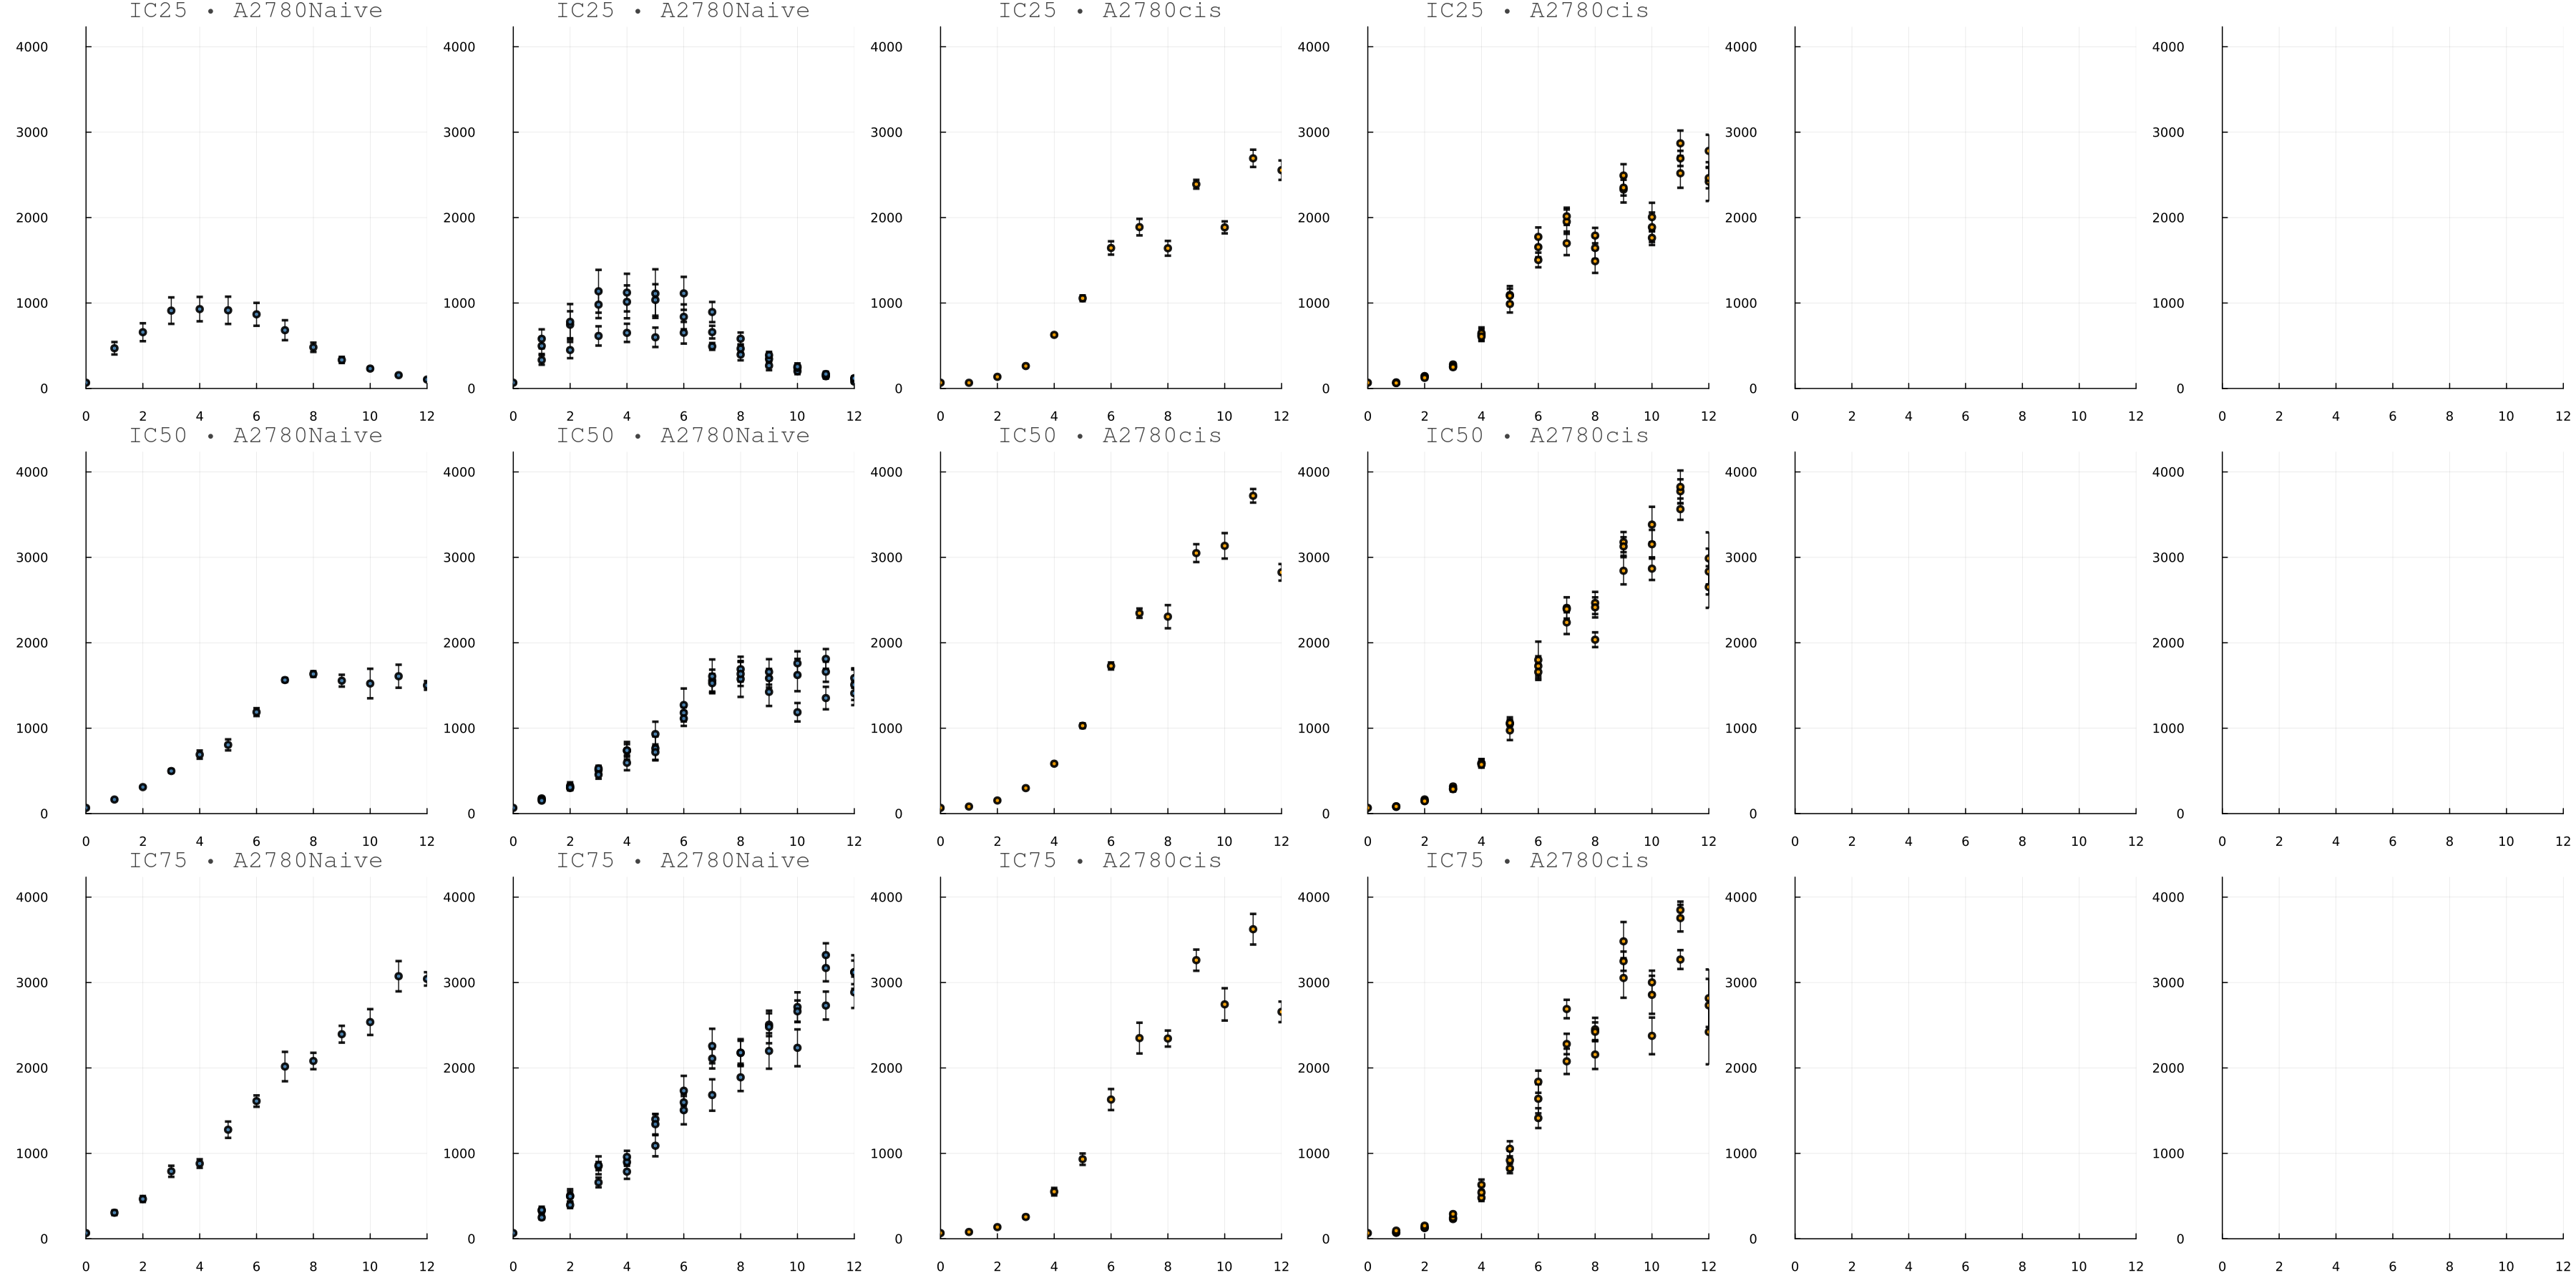

✅ Saved figure to c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis\treated_processed_3x6.png


GKS: could not find font Arial.ttf


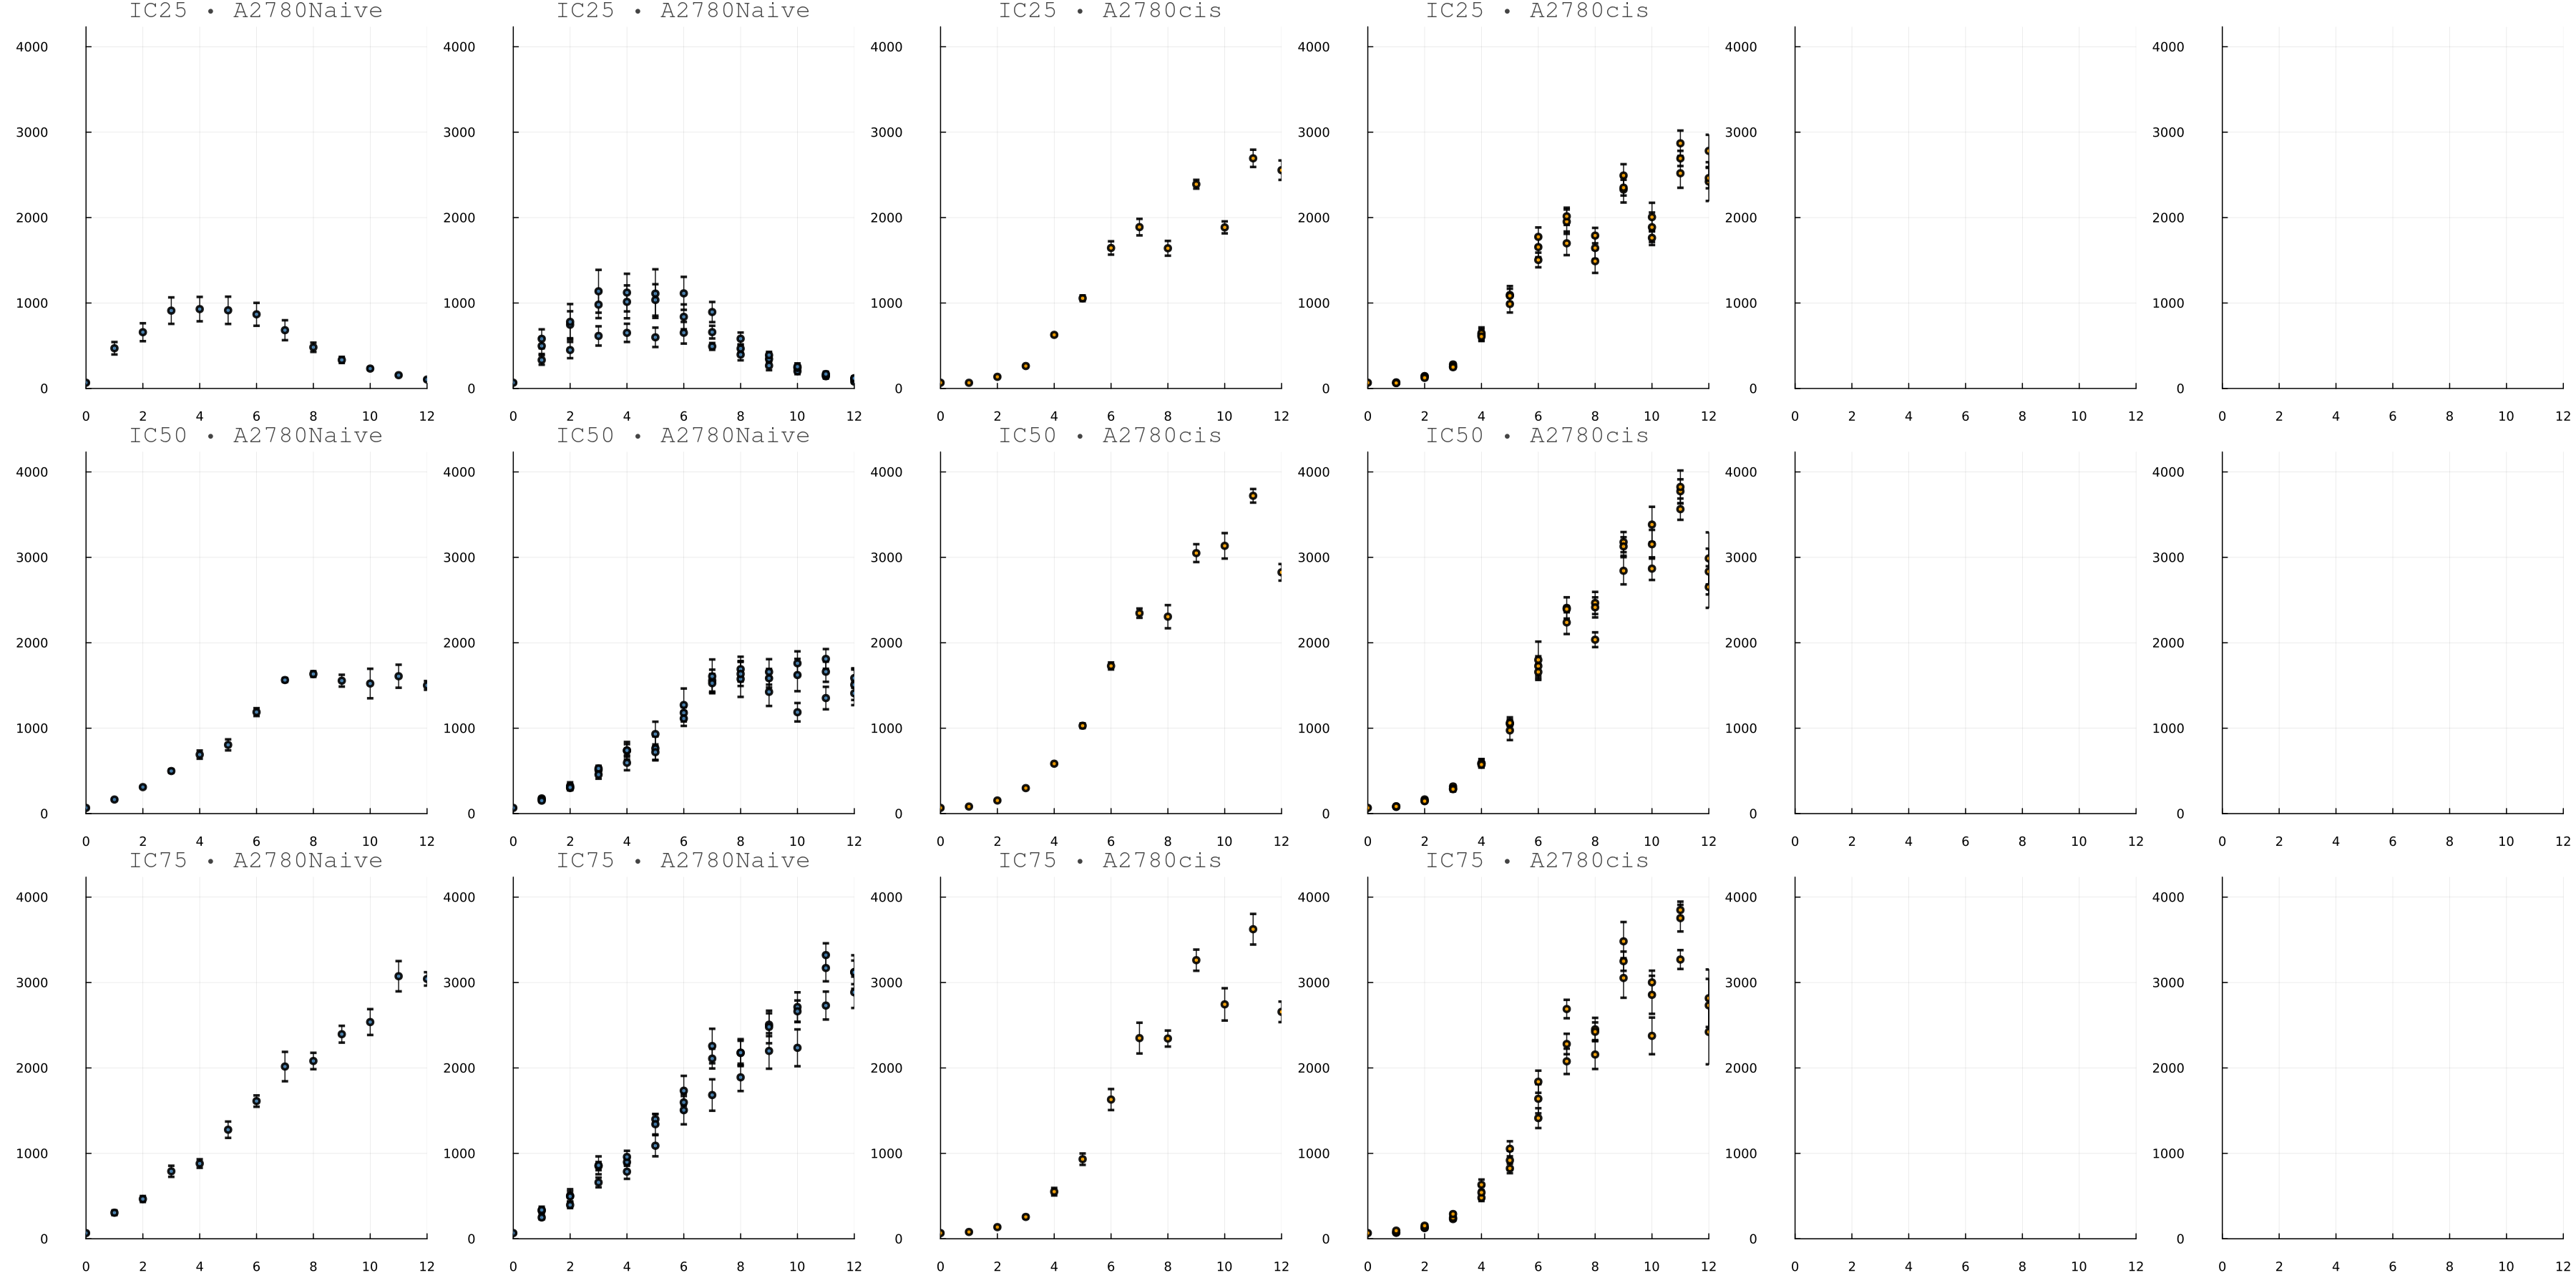

In [10]:
plot_all_treated_processed(IC25_DIR, IC50_DIR, IC75_DIR; ncols=6, save_path=joinpath(OUT_DIR, "treated_processed_3x6.png"))